# QED-C Application-Oriented Benchmarks - MQT Bench Example (New Execution Path)
This notebook demonstrates modularized problem generation using MQT Bench, with execution
and analysis using the new QED-C array-based execution functions.

The list of MQT Bench algorithmic benchmarks can be found at:
https://mqt.readthedocs.io/projects/bench/en/latest/benchmark_selection.html

Configure and run the cell below with the desired execution settings, then proceed to run the remaining cells.

In [1]:
benchmark_name = 'wstate'
min_qubits=2
max_qubits=8
skip_qubits=1
max_circuits=3
num_shots=1000

In [2]:
# Initialize QED-C framework for qiskit (loads execute module)
from _common.qedc_init import qedc_benchmarks_init
qedc_benchmarks_init("qiskit")

# MQT Bench:
from mqt.bench import get_benchmark, BenchmarkLevel

# QED-C:
from _common import metrics
import execute as ex

# IBM Qiskit:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

## Part 1: Problem Generation with MQT Bench
The code below grabs __circuits__ from MQT Bench from _min_qubits_ to _max_qubits_
using _skip_qubits_ and _max_circuits_.

Note that we do not get any metadata from MQT Bench; we initialize __metadata__ as an
empty dictionary and later use the QED-C metrics module to compute additional metrics.

In [3]:
def get_mqt_circuits(
    benchmark_name:str, 
    min_qubits:int, 
    max_qubits:int, 
    skip_qubits:int, 
    max_circuits:int
    ):
    circuits = {}
    for n_qubits in range(min_qubits, max_qubits+1, skip_qubits):
        circuits_n_qubits = {}
        for idx in range(1, max_circuits+1):
            circuits_n_qubits[str(idx)] = get_benchmark(benchmark=benchmark_name, level=BenchmarkLevel.ALG, circuit_size=n_qubits)
        circuits[str(n_qubits)] = circuits_n_qubits
    return circuits

In [4]:
# Using the above function to grab circuits.
circuits = get_mqt_circuits(benchmark_name, min_qubits, max_qubits, skip_qubits, max_circuits)

# No metadata from MQT Bench.
metadata = {}

print(f"Circuits ({sum(len(g) for g in circuits.values())} total):")
for nq in circuits:
    print(f"  {nq} qubits: {len(circuits[nq])} circuits")

Circuits (21 total):
  2 qubits: 3 circuits
  3 qubits: 3 circuits
  4 qubits: 3 circuits
  5 qubits: 3 circuits
  6 qubits: 3 circuits
  7 qubits: 3 circuits
  8 qubits: 3 circuits


## Part 2: Execution using QED-C submit_circuits()

We use the QED-C `submit_circuits()` convenience function, which handles:
1. Executing all circuits as an array
2. Storing execution timing (elapsed_time, exec_time) per circuit
3. Calling the result handler for each circuit

We first compute circuit metrics (depth, etc.), then define a result handler that
computes fidelity by comparing against a noiseless simulator run.

In [5]:
def ideal_dist(qc, num_shots):
    """Compute ideal distribution for a single circuit by running on noiseless simulator."""
    sim = Aer.get_backend("aer_simulator")
    tqc = transpile(qc, sim)
    result = sim.run(tqc, shots=num_shots).result()
    return result.get_counts()

def execution_handler(qc, result, num_qubits, circuit_id, num_shots):
    """Process each circuit result: compute fidelity vs ideal and store."""
    correct = ideal_dist(qc, int(num_shots) if num_shots else 1000)
    counts = result.get_counts()
    
    hf_fidelity = metrics.hellinger_fidelity_with_expected(counts, correct)
    polarization_fidelity = metrics.polarization_fidelity(counts, correct)
    
    metrics.store_metric(num_qubits, circuit_id, "hf_fidelity", hf_fidelity)
    metrics.store_metric(num_qubits, circuit_id, "fidelity", polarization_fidelity)

In [6]:
# Initialize metrics and register the result handler
metrics.init_metrics()
ex.init_execution(execution_handler)
ex.set_execution_target('qasm_simulator', context=f"{benchmark_name} Benchmark")

# Compute circuit metrics (depth, normalized depth, etc.)
ex.compute_all_circuit_metrics(circuits)

# Execute all circuits and process results (stores timing, calls result_handler)
ex.submit_circuits(circuits, num_shots=num_shots)

# Finalize all groups and end metrics
metrics.finalize_all_groups()

... execution starting at May 02, 2026 05:53:05 UTC


C:\Users\m\.conda\envs\qiskit-test-2.0\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\m\.conda\envs\qiskit-test-2.0\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will invalidate the backend's gate durations and error rates.
  pm = generate_preset_pass_manager(


************
Average Circuit Algorithmic Depth, xi for the 2 qubit group = 5, 0.4
Average Normalized Transpiled Depth, xi, 2q gates for the 2 qubit group = 7, 0.286, 2.0
Average Creation, Elapsed, Execution Time for the 2 qubit group = 0, 0.234, 0.125 secs
Average Hellinger, Normalized Fidelity for the 2 qubit group = 0.995, 0.99

************
Average Circuit Algorithmic Depth, xi for the 3 qubit group = 7, 0.444
Average Normalized Transpiled Depth, xi, 2q gates for the 3 qubit group = 10, 0.308, 4.0
Average Creation, Elapsed, Execution Time for the 3 qubit group = 0, 0.234, 0.125 secs
Average Hellinger, Normalized Fidelity for the 3 qubit group = 0.987, 0.98

************
Average Circuit Algorithmic Depth, xi for the 4 qubit group = 9, 0.462
Average Normalized Transpiled Depth, xi, 2q gates for the 4 qubit group = 13, 0.316, 6.0
Average Creation, Elapsed, Execution Time for the 4 qubit group = 0, 0.234, 0.125 secs
Average Hellinger, Normalized Fidelity for the 4 qubit group = 0.983, 0

## Part 3: Visualization

Now that metrics are stored (circuit depth, fidelity, execution time), we can plot the results.

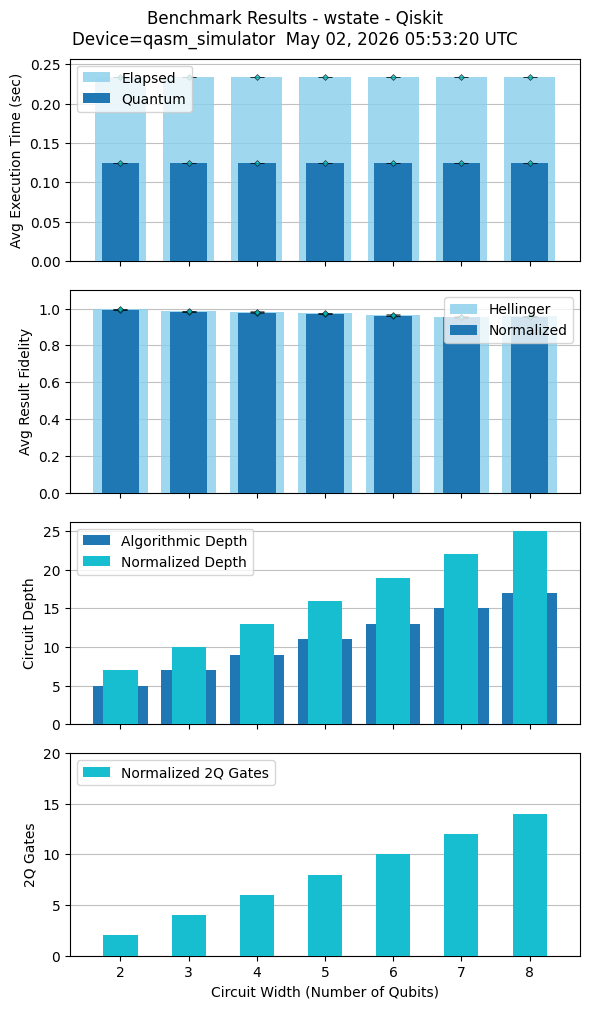

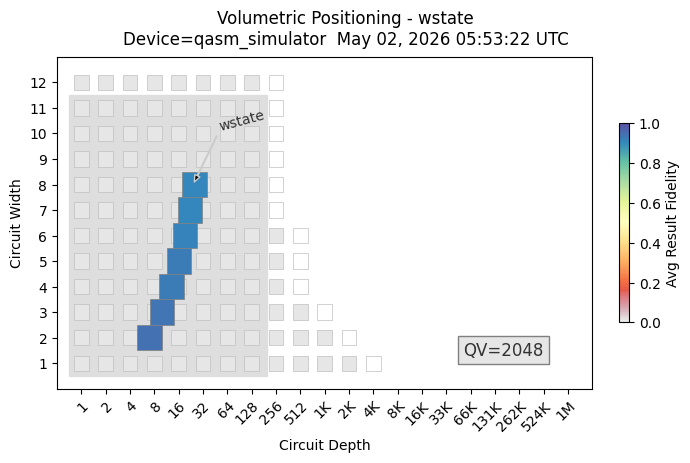

In [7]:
# Set information for plot titles.
provider_name = "Qiskit"
device_name = "qasm_simulator"

benchmark_title = f"{benchmark_name}"
subtitle = f"Benchmark Results - {benchmark_title} - {provider_name}"
metrics.circuit_metrics["subtitle"] = f"device = {device_name}"

# Plot metrics including execution time.
filters = ["execute", "fidelity", "hf_fidelity", "depth", "2q", "vbplot"]
metrics.plot_metrics(subtitle, filters=filters)